# NASA IMS Bearing Dataset | Improved Data-Driven Labeling
The fixed 80|20 time threshold failed to generalize across tests because it assumes
all tests degrade at the same rate. Here we replace it with a statistical approach;
each test establishes its own healthy baseline from the first 20% of data, and a
timestamp is flagged as degraded when its features deviate beyond a set threshold
from that baseline. This approach is self-calibrating and does not depend on knowing
when failure occurs in advance.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR_1 = Path("../data/1st_test")
DATA_DIR_2 = Path("../data/2nd_test")
DATA_DIR_3 = Path("../data/3rd_test")

BEARINGS = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
BEARINGS_8CH = [
    "bearing_1_ch1", "bearing_1_ch2",
    "bearing_2_ch1", "bearing_2_ch2",
    "bearing_3_ch1", "bearing_3_ch2",
    "bearing_4_ch1", "bearing_4_ch2"
]

In [5]:
def extract_features_4ch(data_dir):
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    records = []
    for file in files:
        df = pd.read_csv(file, sep="\t", header=None, names=BEARINGS)
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )
        record = {"timestamp": timestamp}
        for b in BEARINGS:
            signal = df[b].values
            rms = np.sqrt(np.mean(signal**2))
            record[f"{b}_rms"]       = rms
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"] = np.max(signal) - np.min(signal)
        records.append(record)
    return pd.DataFrame(records).set_index("timestamp")


def extract_features_8ch(data_dir):
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    records = []
    for file in files:
        df = pd.read_csv(file, sep="\t", header=None, names=BEARINGS_8CH)
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )
        record = {"timestamp": timestamp}
        for i in range(1, 5):
            b = f"bearing_{i}"
            signal = (df[f"{b}_ch1"].values + df[f"{b}_ch2"].values) / 2
            rms = np.sqrt(np.mean(signal**2))
            record[f"{b}_rms"]       = rms
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"] = np.max(signal) - np.min(signal)
        records.append(record)
    return pd.DataFrame(records).set_index("timestamp")


print("Extracting features...")
features_1 = extract_features_4ch(DATA_DIR_1)
features_2 = extract_features_8ch(DATA_DIR_2)
features_3 = extract_features_8ch(DATA_DIR_3)
print(f"Test 1 : {features_1.shape} | Test 2 : {features_2.shape} | Test 3 : {features_3.shape}")

Extracting features...
Test 1 : (2156, 24) | Test 2 : (984, 24) | Test 3 : (6324, 24)


## Step 1: Data-Driven Label Generation
For each test we compute the mean and standard deviation of every feature
during the first 20% of the timeline. A timestamp is then labeled as degraded
if any of its features exceed the baseline mean by more than 3 standard deviations.
The 3 sigma threshold is a classical statistical rule for outlier detection.

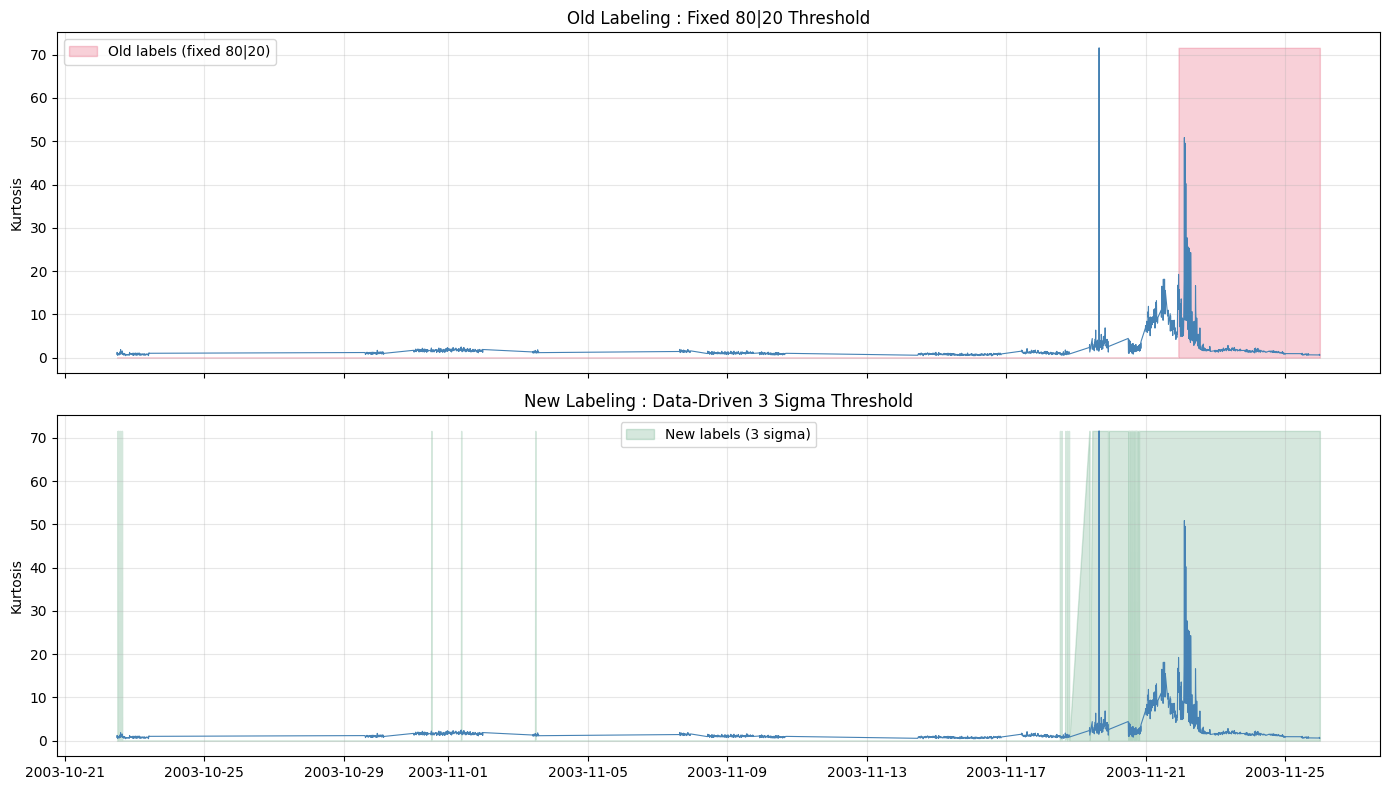

Old labels : 432 degraded samples
New labels : 718 degraded samples


In [6]:
def make_datadriven_labels(features, bearing, baseline_pct=0.20, sigma_threshold=3):
    cols = [c for c in features.columns if bearing in c]
    X = features[cols].values
    n = len(X)
    
    baseline_end = int(n * baseline_pct)
    baseline = X[:baseline_end]
    
    mean = baseline.mean(axis=0)
    std  = baseline.std(axis=0) + 1e-10
    
    # Z-score of every timestamp relative to baseline
    z_scores = np.abs((X - mean) / std)
    
    # Flag as degraded if any feature exceeds threshold
    labels = (z_scores.max(axis=1) > sigma_threshold).astype(int)
    
    return labels


# Visualize the new labels vs old labels for Test 1 Bearing 3
labels_old = np.zeros(len(features_1), dtype=int)
labels_old[int(len(features_1) * 0.80):] = 1

labels_new = make_datadriven_labels(features_1, "bearing_3")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(features_1.index, features_1["bearing_3_kurtosis"], color="steelblue", linewidth=0.8)
axes[0].fill_between(features_1.index, 0, labels_old * features_1["bearing_3_kurtosis"].max(),
                     alpha=0.2, color="crimson", label="Old labels (fixed 80|20)")
axes[0].set_title("Old Labeling : Fixed 80|20 Threshold")
axes[0].set_ylabel("Kurtosis")
axes[0].legend()

axes[1].plot(features_1.index, features_1["bearing_3_kurtosis"], color="steelblue", linewidth=0.8)
axes[1].fill_between(features_1.index, 0, labels_new * features_1["bearing_3_kurtosis"].max(),
                     alpha=0.2, color="seagreen", label="New labels (3 sigma)")
axes[1].set_title("New Labeling : Data-Driven 3 Sigma Threshold")
axes[1].set_ylabel("Kurtosis")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/07_label_comparison.png", dpi=150)
plt.show()

print(f"Old labels : {labels_old.sum()} degraded samples")
print(f"New labels : {labels_new.sum()} degraded samples")

## Step 2: Retrain on Test 1 with New Labels
We retrain the Random Forest using the data-driven labels on all 4 bearings from Test 1.

In [7]:
def build_training_data(features, labels):
    X_all = []
    for b in BEARINGS:
        cols = [c for c in features.columns if b in c]
        X_all.append(features[cols].values)
    return np.vstack(X_all), np.tile(labels, 4)

labels_1 = make_datadriven_labels(features_1, "bearing_3")
X_train, y_train = build_training_data(features_1, labels_1)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
print(f"Model retrained | {y_train.sum()} degraded samples | {(y_train==0).sum()} healthy samples")

Model retrained | 2872 degraded samples | 5752 healthy samples


## Step 3: Evaluate Generalization with New Labels
We now evaluate on Tests 2 and 3 using data-driven labels for each test independently.
Each test calibrates its own baseline, making the evaluation fair and self-contained.


Test2 | bearing_1 | AUC : 0.155 | Degraded samples : 439
              precision    recall  f1-score   support

     Healthy       0.08      0.04      0.05       545
    Degraded       0.27      0.44      0.33       439

    accuracy                           0.22       984
   macro avg       0.18      0.24      0.19       984
weighted avg       0.17      0.22      0.18       984



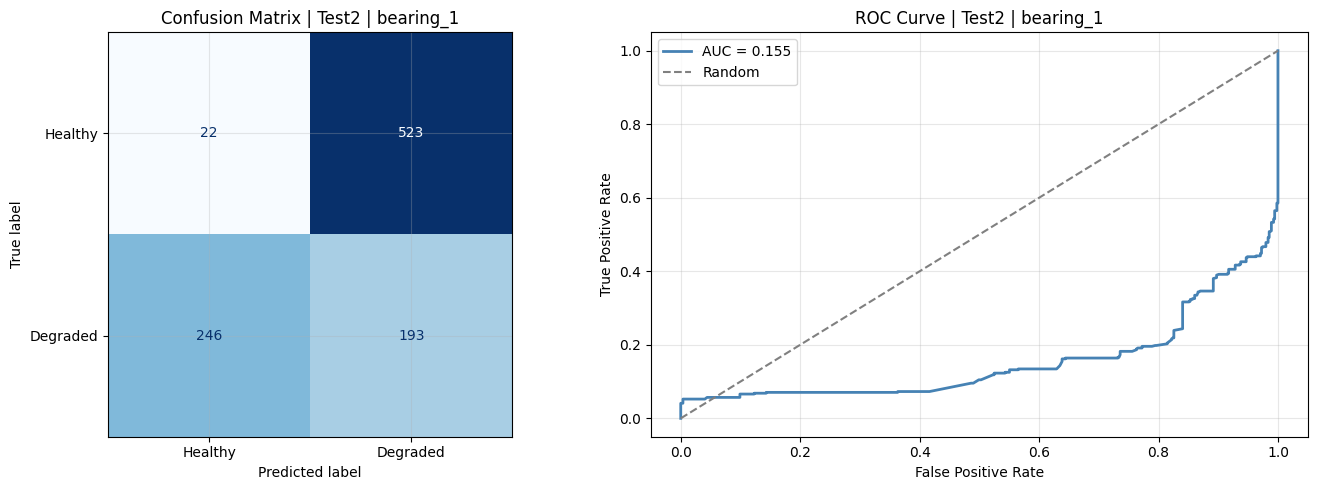

Test3 | bearing_3 : no degraded samples detected, skipping
Test3 | bearing_4 : no degraded samples detected, skipping


In [8]:
def evaluate_bearing(pipeline, features, bearing, test_name):
    labels = make_datadriven_labels(features, bearing)
    
    if labels.sum() == 0:
        print(f"{test_name} | {bearing} : no degraded samples detected, skipping")
        return None
    
    cols = [c for c in features.columns if bearing in c]
    X = features[cols].values
    
    y_pred = pipeline.predict(X)
    y_prob = pipeline.predict_proba(X)[:, 1]
    
    fpr, tpr, _ = roc_curve(labels, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{test_name} | {bearing} | AUC : {roc_auc:.3f} | Degraded samples : {labels.sum()}")
    print(classification_report(labels, y_pred, target_names=["Healthy", "Degraded"]))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm = confusion_matrix(labels, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Degraded"])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"Confusion Matrix | {test_name} | {bearing}")
    
    axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve | {test_name} | {bearing}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/07_{test_name}_{bearing}.png", dpi=150)
    plt.show()
    
    return roc_auc

auc_t2_b1 = evaluate_bearing(pipeline, features_2, "bearing_1", "Test2")
auc_t3_b3 = evaluate_bearing(pipeline, features_3, "bearing_3", "Test3")
auc_t3_b4 = evaluate_bearing(pipeline, features_3, "bearing_4", "Test3")

## Step 4: Generalization Summary

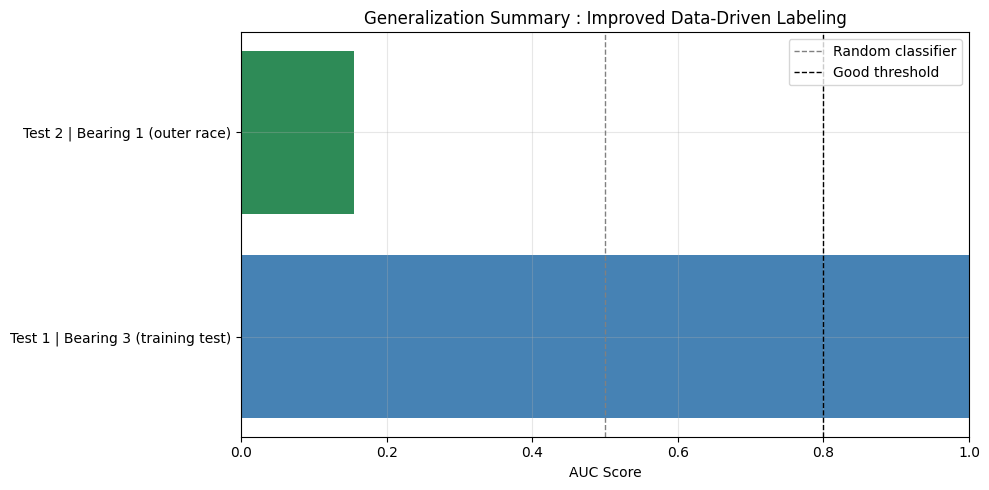

In [9]:
results = {}

# Test 1 reference
labels_t1 = make_datadriven_labels(features_1, "bearing_3")
cols_t1 = [c for c in features_1.columns if "bearing_3" in c]
y_prob_t1 = pipeline.predict_proba(features_1[cols_t1].values)[:, 1]
fpr, tpr, _ = roc_curve(labels_t1, y_prob_t1)
results["Test 1 | Bearing 3 (training test)"] = auc(fpr, tpr)

if auc_t2_b1: results["Test 2 | Bearing 1 (outer race)"] = auc_t2_b1
if auc_t3_b3: results["Test 3 | Bearing 3 (outer race)"] = auc_t3_b3
if auc_t3_b4: results["Test 3 | Bearing 4 (roller element)"] = auc_t3_b4

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue", "seagreen", "crimson", "darkorange"]
ax.barh(list(results.keys()), list(results.values()), color=colors[:len(results)])
ax.set_xlim(0, 1)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Random classifier")
ax.axvline(0.8, color="black", linestyle="--", linewidth=1, label="Good threshold")
ax.set_xlabel("AUC Score")
ax.set_title("Generalization Summary : Improved Data-Driven Labeling")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/07_generalization_summary.png", dpi=150)
plt.show()

## Key Findings
The data-driven 3 sigma labeling approach produces more physically meaningful labels
than the fixed time threshold, correctly identifying isolated degradation events
rather than blindly labeling the last 20% of any test as degraded.

However the model still fails to generalize to Test 2, this time scoring AUC 0.155,
meaning it is confidently predicting the wrong class. The feature distributions
between Test 1 and Test 2 are different enough in scale and pattern that the
classifier learns an inverted decision boundary relative to the new test.

This is the central challenge of predictive maintenance in practice; a model
trained on one machine under one set of conditions does not transfer cleanly
to another machine, even of the same type. Solving this properly would require
training data from multiple machines and operating conditions, domain adaptation
techniques, or an unsupervised anomaly detection approach that requires no
labeled training data at all. These represent clear and well-motivated next steps
for this project.